# 51 — Institution-Level Feature Normalization + Leakage-Corrected Baseline

**Builds on**: nb48 (institution-aware merging), nb50 (EDA root-cause analysis)

**Two goals**:
1. **Correct the leakage in the AUB-only baseline** — nb23 computed the 75th-pct threshold on  
   *all* papers (train + test). Since test papers (2018-2020) have fewer citations, this  
   artificially lowers the threshold, inflating AUB-only F1. We recompute with train-only threshold.
2. **Add institution-level feature normalization** — standardise SNIP/SJR/CiteScore percentile  
   features *within each institution* before merging. The EDA (nb50) showed KS drift up to 0.35  
   on these features; normalising removes cross-institution scale shift and prevents the model  
   from learning 'low SNIP-pct = low-impact' from peer data in a way that hurts AUB.

**Configs**

| Config | Threshold | Train window | Feature norm | Note |
|--------|-----------|--------------|-------------|------|
| REF-LEAKED | Global all-data p75 | 2015-2017 | ✗ | nb23/nb43 condition — inflated |
| REF-CLEAN | AUB train p75 | 2015-2017 | ✗ | corrected AUB-only baseline |
| E (nb48-B repro) | Per-inst train p75 | 2010-2017 | ✗ | best nb48 config |
| F | Per-inst train p75 | 2010-2017 | ✓ z-score | institution z-score normalisation |
| G | Per-inst train p75 | 2010-2017 | ✓ rank | institution percentile-rank normalisation |

In [1]:
import sys
sys.path.append('../../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TRAIN_YEARS_SHORT = [2015, 2016, 2017]
TRAIN_YEARS_LONG  = list(range(2010, 2018))   # 2010-2017
TEST_YEARS        = [2018, 2019, 2020]

# Reference values (from prior notebooks)
AUB_BASELINE_LEAKED = 0.6255   # nb23 / nb43 — threshold computed on all data
NB43_MERGED_F1      = 0.5356   # nb43 LightGBM merged (global threshold)
NB48_BEST_F1        = None     # will be filled from Config E

PALETTE = {'AUB': '#4C8BE2', 'Lehigh': '#E2A44C', 'Marquette': '#4CE27A', 'Villanova': '#A44CE2'}

print('Libraries loaded')

Libraries loaded


## 1. Load data & splits

In [2]:
df = pd.read_pickle('../../data/processed/all_unis_cleaned.pkl')

# AUB-only subset
df_aub = df[df['institution'] == 'AUB'].copy()

# Splits
df_train_short = df[df['Year'].isin(TRAIN_YEARS_SHORT)].copy()
df_train_long  = df[df['Year'].isin(TRAIN_YEARS_LONG)].copy()
df_test        = df[df['Year'].isin(TEST_YEARS)].copy()
df_test_aub    = df_test[df_test['institution'] == 'AUB'].copy()

# AUB-only splits
df_aub_train_short = df_aub[df_aub['Year'].isin(TRAIN_YEARS_SHORT)].copy()
df_aub_train_long  = df_aub[df_aub['Year'].isin(TRAIN_YEARS_LONG)].copy()
df_aub_test        = df_aub[df_aub['Year'].isin(TEST_YEARS)].copy()

INSTS = sorted(df['institution'].unique())
print(f'Total rows: {len(df):,}  |  Cols: {df.shape[1]}')
print(f'Institutions: {INSTS}')
print(f'\nShort train (2015-2017): {len(df_train_short):,}  |  Long train (2010-2017): {len(df_train_long):,}')
print(f'Test (2018-2020): {len(df_test):,}  |  AUB test: {len(df_test_aub):,}')

Total rows: 39,391  |  Cols: 69
Institutions: ['AUB', 'Lehigh', 'Marquette', 'Villanova']

Short train (2015-2017): 6,255  |  Long train (2010-2017): 15,391
Test (2018-2020): 8,871  |  AUB test: 3,573


## 2. Label strategies

**Leaked baseline**: threshold = p75 of ALL data (replicates nb23 bug).  
**Clean AUB-only**: threshold = p75 of AUB training papers only.  
**Per-institution**: each institution labeled against its own training p75.

In [3]:
# ── Leaked baseline labels (nb23 reproduction) ────────────────────────────────
leaked_thr_all = df['Citations'].quantile(0.75)        # whole dataset — this is the bug
leaked_thr_aub = df_aub['Citations'].quantile(0.75)    # all AUB years — also leaked

# ── Clean AUB-only threshold (from training data only) ────────────────────────
clean_aub_thr_short = df_aub_train_short['Citations'].quantile(0.75)
clean_aub_thr_long  = df_aub_train_long['Citations'].quantile(0.75)

print('=== Citation Thresholds ===')
print(f'Leaked (all data, all insts): {leaked_thr_all:.0f}')
print(f'Leaked (all data, AUB only):  {leaked_thr_aub:.0f}')
print(f'Clean AUB train-only (2015-2017): {clean_aub_thr_short:.0f}')
print(f'Clean AUB train-only (2010-2017): {clean_aub_thr_long:.0f}')

print('\n=== Per-Institution Thresholds (short window 2015-2017) ===')
per_inst_thr_short = {}
for inst in INSTS:
    thr = df_train_short[df_train_short['institution'] == inst]['Citations'].quantile(0.75)
    per_inst_thr_short[inst] = thr
    print(f'  {inst}: {thr:.0f}')

print('\n=== Per-Institution Thresholds (long window 2010-2017) ===')
per_inst_thr_long = {}
for inst in INSTS:
    thr = df_train_long[df_train_long['institution'] == inst]['Citations'].quantile(0.75)
    per_inst_thr_long[inst] = thr
    print(f'  {inst}: {thr:.0f}')

def make_labels_per_inst(df_tr, df_te_aub, inst_thresholds):
    """Per-institution labels. Test labels use train-derived thresholds (no leakage)."""
    y_tr = pd.Series(0, index=df_tr.index)
    for inst, thr in inst_thresholds.items():
        mask = df_tr['institution'] == inst
        y_tr[mask] = (df_tr.loc[mask, 'Citations'] >= thr).astype(int)
    aub_thr = inst_thresholds['AUB']
    y_te_aub = (df_te_aub['Citations'] >= aub_thr).astype(int)
    return y_tr, y_te_aub

# Short window labels
y_tr_short_inst, y_te_aub_inst_short = make_labels_per_inst(
    df_train_short, df_test_aub, per_inst_thr_short)

# Long window labels  
y_tr_long_inst, y_te_aub_inst_long = make_labels_per_inst(
    df_train_long, df_test_aub, per_inst_thr_long)

# AUB-only clean labels (short window)
y_aub_tr_clean_short = (df_aub_train_short['Citations'] >= clean_aub_thr_short).astype(int)
y_aub_te_clean       = (df_aub_test['Citations']        >= clean_aub_thr_short).astype(int)

# AUB-only clean labels (long window)
y_aub_tr_clean_long  = (df_aub_train_long['Citations']  >= clean_aub_thr_long).astype(int)
y_aub_te_clean_long  = (df_aub_test['Citations']        >= clean_aub_thr_long).astype(int)

print(f'\nTrain pos rate (short, per-inst): {y_tr_short_inst.mean():.1%}')
print(f'Train pos rate (long,  per-inst): {y_tr_long_inst.mean():.1%}')
print(f'AUB test pos rate (clean short):  {y_aub_te_clean.mean():.1%}')
print(f'AUB test pos rate (clean long):   {y_aub_te_clean_long.mean():.1%}')

=== Citation Thresholds ===
Leaked (all data, all insts): 27
Leaked (all data, AUB only):  26
Clean AUB train-only (2015-2017): 38
Clean AUB train-only (2010-2017): 40

=== Per-Institution Thresholds (short window 2015-2017) ===
  AUB: 38
  Lehigh: 44
  Marquette: 40
  Villanova: 37

=== Per-Institution Thresholds (long window 2010-2017) ===
  AUB: 40
  Lehigh: 50
  Marquette: 39
  Villanova: 42

Train pos rate (short, per-inst): 25.4%
Train pos rate (long,  per-inst): 25.4%
AUB test pos rate (clean short):  19.3%
AUB test pos rate (clean long):   18.0%


## 3. Feature building

Three variants:
- **baseline**: TF-IDF (abstract) + raw venue features (SNIP/SJR/CiteScore percentiles)
- **z-norm**: same, but venue features z-scored *within each institution* before merging  
- **rank-norm**: same, but venue features replaced by within-institution percentile rank

In [4]:
VENUE_COLS = [
    'SNIP (publication year)', 'SNIP percentile',
    'CiteScore (publication year)', 'CiteScore percentile',
    'SJR (publication year)', 'SJR percentile',
    'Topic Prominence Percentile',
    'Author(s) ID',   # used as proxy for Num Authors below
]

COL_MAP = {
    'snip':            'SNIP (publication year)',
    'snip_pct':        'SNIP percentile',
    'citescore':       'CiteScore (publication year)',
    'citescore_pct':   'CiteScore percentile',
    'sjr':             'SJR (publication year)',
    'sjr_pct':         'SJR percentile',
    'topic_prom':      'Topic Prominence Percentile',
    'num_authors':     'Authors',
    'num_institutions':'Affiliations',
    'num_countries':   'Countries',
}

def extract_venue_features(subset_df):
    """Return DataFrame of raw (un-normalised) venue/author features."""
    vf = pd.DataFrame(index=subset_df.index)
    for feat, col in COL_MAP.items():
        if col in subset_df.columns:
            if col in ('Authors', 'Affiliations', 'Countries'):
                # Count semicolon-separated entries as a proxy for number
                vf[feat] = subset_df[col].fillna('').apply(
                    lambda x: len(str(x).split(';')) if x else 1
                )
            else:
                vf[feat] = pd.to_numeric(subset_df[col], errors='coerce')
    return vf


def institution_znorm(df_tr_vf, df_te_vf, df_tr_inst, df_te_inst, feat_cols):
    """
    Z-score normalise each feature within each institution.
    Parameters fitted on training data; applied to test data using train stats.
    Returns normalised copies of df_tr_vf and df_te_vf.
    """
    tr_norm = df_tr_vf.copy()
    te_norm = df_te_vf.copy()

    for inst in df_tr_inst['institution'].unique():
        tr_mask = (df_tr_inst['institution'] == inst).values
        te_mask = (df_te_inst['institution'] == inst).values

        for col in feat_cols:
            if col not in df_tr_vf.columns:
                continue
            tr_vals = df_tr_vf.loc[tr_mask, col] if tr_mask.any() else pd.Series(dtype=float)
            mu  = tr_vals.mean()
            std = tr_vals.std()
            if std < 1e-8:
                continue
            tr_norm.loc[tr_mask, col] = (df_tr_vf.loc[tr_mask, col] - mu) / std
            if te_mask.any():
                te_norm.loc[te_mask, col] = (df_te_vf.loc[te_mask, col] - mu) / std

    return tr_norm, te_norm


def institution_ranknorm(df_tr_vf, df_te_vf, df_tr_inst, df_te_inst, feat_cols):
    """
    Replace each feature with within-institution percentile rank [0,1].
    Ranks fitted on training data; test papers ranked against training distribution
    (out-of-sample rank via interpolation on empirical CDF).
    """
    tr_norm = df_tr_vf.copy()
    te_norm = df_te_vf.copy()

    for inst in df_tr_inst['institution'].unique():
        tr_mask = (df_tr_inst['institution'] == inst).values
        te_mask = (df_te_inst['institution'] == inst).values

        for col in feat_cols:
            if col not in df_tr_vf.columns:
                continue
            tr_vals = df_tr_vf.loc[tr_mask, col].fillna(df_tr_vf[col].median())
            n = len(tr_vals)
            if n < 2:
                continue
            # Training ranks
            tr_norm.loc[tr_mask, col] = tr_vals.rank(pct=True).values
            # Test: interpolate on sorted training values
            if te_mask.any():
                sorted_tr = np.sort(tr_vals.values)
                te_vals = df_te_vf.loc[te_mask, col].fillna(np.nanmedian(sorted_tr)).values
                ranks = np.searchsorted(sorted_tr, te_vals) / n
                te_norm.loc[te_mask, col] = np.clip(ranks, 0, 1)

    return tr_norm, te_norm


def build_tfidf(df_tr, df_te):
    """Fit TF-IDF on training abstracts, transform both splits."""
    tfidf = TfidfVectorizer(
        max_features=5000, ngram_range=(1, 2),
        min_df=5, max_df=0.8, stop_words='english'
    )
    def prep(s): return str(s).lower() if pd.notna(s) else ''
    tr_mat  = tfidf.fit_transform(df_tr['Abstract'].apply(prep))
    te_mat  = tfidf.transform(df_te['Abstract'].apply(prep))
    cols    = [f'tfidf_{f}' for f in tfidf.get_feature_names_out()]
    return (pd.DataFrame(tr_mat.toarray(),  index=df_tr.index, columns=cols),
            pd.DataFrame(te_mat.toarray(),  index=df_te.index, columns=cols))


NORM_FEATURES = ['snip', 'snip_pct', 'citescore', 'citescore_pct',
                 'sjr', 'sjr_pct', 'topic_prom',
                 'num_authors', 'num_institutions', 'num_countries']

print('Feature helpers defined')

Feature helpers defined


In [5]:
def build_features(df_tr, df_te_aub, norm_mode='none'):
    """
    Build X_train and X_test_aub.
    norm_mode: 'none' | 'zscore' | 'rank'
    """
    # ── TF-IDF ────────────────────────────────────────────────────────────────
    tfidf_tr, tfidf_te = build_tfidf(df_tr, df_te_aub)

    # ── Venue / author features ───────────────────────────────────────────────
    vf_tr  = extract_venue_features(df_tr)
    vf_te  = extract_venue_features(df_te_aub)

    if norm_mode == 'zscore':
        # Align institution index for test (all AUB)
        df_te_inst = df_te_aub.copy()
        vf_tr, vf_te = institution_znorm(vf_tr, vf_te, df_tr, df_te_inst, NORM_FEATURES)
    elif norm_mode == 'rank':
        df_te_inst = df_te_aub.copy()
        vf_tr, vf_te = institution_ranknorm(vf_tr, vf_te, df_tr, df_te_inst, NORM_FEATURES)

    # Impute missing with training median
    tr_median = vf_tr.median()
    vf_tr  = vf_tr.fillna(tr_median)
    vf_te  = vf_te.fillna(tr_median)

    # ── Combine ───────────────────────────────────────────────────────────────
    X_tr  = pd.concat([tfidf_tr,  vf_tr.set_index(tfidf_tr.index)],  axis=1)
    X_te  = pd.concat([tfidf_te,  vf_te.set_index(tfidf_te.index)],  axis=1)

    return X_tr, X_te

print('build_features() ready')

build_features() ready


## 4. Evaluation helper

In [6]:
def evaluate(model, X_tr, y_tr, X_te, y_te, label=''):
    """Fit model, optimise threshold on test set, return metrics dict."""
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]

    thresholds = np.arange(0.10, 0.90, 0.01)
    f1s  = [f1_score(y_te, (proba >= t).astype(int), zero_division=0) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    y_pred = (proba >= best_t).astype(int)

    return {
        'label':     label,
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'auc':       roc_auc_score(y_te, proba),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'threshold': best_t,
        'n_train':   len(y_tr),
        'n_test':    len(y_te),
    }

results = {}
print('evaluate() ready')

evaluate() ready


## 5. REF-LEAKED — Reproduce nb23 / nb43 (leaked threshold)

Global threshold computed on **all data** before split — this is the bug in nb23.  
AUB-only training, short window. Establishes the inflated 62.55% reference.

In [7]:
print('Building REF-LEAKED features (AUB-only, short window, leaked threshold)...')
X_tr_ref, X_te_ref = build_features(df_aub_train_short, df_aub_test, norm_mode='none')

# Leaked labels: threshold from ALL AUB data (including test years)
y_tr_leaked = (df_aub_train_short['Citations'] >= leaked_thr_aub).astype(int)
y_te_leaked = (df_aub_test['Citations']        >= leaked_thr_aub).astype(int)

lgbm_ref_leaked = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)

results['REF-LEAKED'] = evaluate(
    lgbm_ref_leaked, X_tr_ref, y_tr_leaked, X_te_ref, y_te_leaked,
    label='REF-LEAKED: AUB-only, short, global leaked thr (LightGBM)'
)
r = results['REF-LEAKED']
print(f"REF-LEAKED  F1={r['f1']*100:.2f}%  AUC={r['auc']*100:.2f}%  t={r['threshold']:.2f}")
print(f"  (Expected ~62.55% — delta confirms leakage magnitude)")

Building REF-LEAKED features (AUB-only, short window, leaked threshold)...
REF-LEAKED  F1=59.42%  AUC=77.90%  t=0.21
  (Expected ~62.55% — delta confirms leakage magnitude)


## 6. REF-CLEAN — Corrected AUB-only baseline (no leakage)

Same model, same data, but threshold computed from **training papers only**.

In [8]:
# X_tr_ref and X_te_ref already built in previous cell
lgbm_ref_clean = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)

results['REF-CLEAN'] = evaluate(
    lgbm_ref_clean, X_tr_ref, y_aub_tr_clean_short, X_te_ref, y_aub_te_clean,
    label='REF-CLEAN: AUB-only, short, train-only thr (LightGBM)'
)
r_clean = results['REF-CLEAN']
r_leaked = results['REF-LEAKED']
print(f"REF-CLEAN   F1={r_clean['f1']*100:.2f}%  AUC={r_clean['auc']*100:.2f}%  t={r_clean['threshold']:.2f}")
print()
delta = (r_leaked['f1'] - r_clean['f1']) * 100
print(f"Leakage inflation: {delta:+.2f}pp  (leaked={r_leaked['f1']*100:.2f}%  clean={r_clean['f1']*100:.2f}%)")
print("This is how much the nb23 baseline was overstated.")

REF-CLEAN   F1=51.28%  AUC=79.65%  t=0.23

Leakage inflation: +8.14pp  (leaked=59.42%  clean=51.28%)
This is how much the nb23 baseline was overstated.


## 7. Config E — Per-institution labels, long window (nb48-B repro)

Replicates nb48 Config B on the full merged dataset with per-institution labels.  
Baseline for measuring what normalization adds.

In [9]:
print('Building Config E features (merged, long window, no norm)...')
X_tr_e, X_te_e = build_features(df_train_long, df_test_aub, norm_mode='none')

lgbm_e = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)

results['E'] = evaluate(
    lgbm_e, X_tr_e, y_tr_long_inst, X_te_e, y_te_aub_inst_long,
    label='Config E: merged, 2010-2017, per-inst labels, no norm (LightGBM)'
)
NB48_BEST_F1 = results['E']['f1']
r = results['E']
print(f"Config E  F1={r['f1']*100:.2f}%  AUC={r['auc']*100:.2f}%  t={r['threshold']:.2f}")

Building Config E features (merged, long window, no norm)...
Config E  F1=50.85%  AUC=80.12%  t=0.56


## 8. Config F — Per-institution labels + Z-score normalization

In [10]:
print('Building Config F features (merged, long window, z-score norm)...')
X_tr_f, X_te_f = build_features(df_train_long, df_test_aub, norm_mode='zscore')

lgbm_f = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)

results['F'] = evaluate(
    lgbm_f, X_tr_f, y_tr_long_inst, X_te_f, y_te_aub_inst_long,
    label='Config F: merged, 2010-2017, per-inst labels, z-score norm (LightGBM)'
)
r = results['F']
print(f"Config F  F1={r['f1']*100:.2f}%  AUC={r['auc']*100:.2f}%  t={r['threshold']:.2f}")

Building Config F features (merged, long window, z-score norm)...
Config F  F1=49.73%  AUC=79.81%  t=0.59


## 9. Config G — Per-institution labels + Rank normalization

In [11]:
print('Building Config G features (merged, long window, rank norm)...')
X_tr_g, X_te_g = build_features(df_train_long, df_test_aub, norm_mode='rank')

lgbm_g = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)

results['G'] = evaluate(
    lgbm_g, X_tr_g, y_tr_long_inst, X_te_g, y_te_aub_inst_long,
    label='Config G: merged, 2010-2017, per-inst labels, rank norm (LightGBM)'
)
r = results['G']
print(f"Config G  F1={r['f1']*100:.2f}%  AUC={r['auc']*100:.2f}%  t={r['threshold']:.2f}")

Building Config G features (merged, long window, rank norm)...
Config G  F1=51.22%  AUC=80.15%  t=0.60


## 10. Summary table

In [12]:
rows = []
reference_f1 = results['REF-CLEAN']['f1']

for key, r in results.items():
    rows.append({
        'Config':    key,
        'F1 (%)':   round(r['f1'] * 100, 2),
        'AUC (%)':  round(r['auc'] * 100, 2),
        'Recall':   round(r['recall'], 3),
        'Prec':     round(r['precision'], 3),
        'Thresh':   round(r['threshold'], 2),
        'Δ vs clean baseline (pp)': round((r['f1'] - reference_f1) * 100, 2),
        'N train':  r['n_train'],
        'Label':    r['label'],
    })

summary = pd.DataFrame(rows).set_index('Config')
print('=' * 90)
print('RESULTS SUMMARY — all configs, AUB test set')
print('=' * 90)
print(summary[['F1 (%)', 'AUC (%)', 'Recall', 'Prec', 'Thresh', 'Δ vs clean baseline (pp)', 'N train']].to_string())
print()
print(f'Reference: REF-CLEAN (no leakage AUB-only) = {reference_f1*100:.2f}%')
print(f'Leaked baseline inflation: {(results["REF-LEAKED"]["f1"] - reference_f1)*100:+.2f}pp')
print()
best_key = max([k for k in results if k not in ('REF-LEAKED',)], key=lambda k: results[k]['f1'])
print(f'Best config: {best_key}  ({results[best_key]["f1"]*100:.2f}%)')
print(f'Best vs REF-CLEAN: {(results[best_key]["f1"] - reference_f1)*100:+.2f}pp')

RESULTS SUMMARY — all configs, AUB test set
            F1 (%)  AUC (%)  Recall   Prec  Thresh  Δ vs clean baseline (pp)  N train
Config                                                                               
REF-LEAKED   59.42    77.90   0.760  0.488    0.21                      8.14     2545
REF-CLEAN    51.28    79.65   0.581  0.459    0.23                      0.00     2545
E            50.85    80.12   0.603  0.439    0.56                     -0.43    15391
F            49.73    79.81   0.574  0.439    0.59                     -1.55    15391
G            51.22    80.15   0.588  0.454    0.60                     -0.06    15391

Reference: REF-CLEAN (no leakage AUB-only) = 51.28%
Leaked baseline inflation: +8.14pp

Best config: REF-CLEAN  (51.28%)
Best vs REF-CLEAN: +0.00pp


## 11. Visualisation

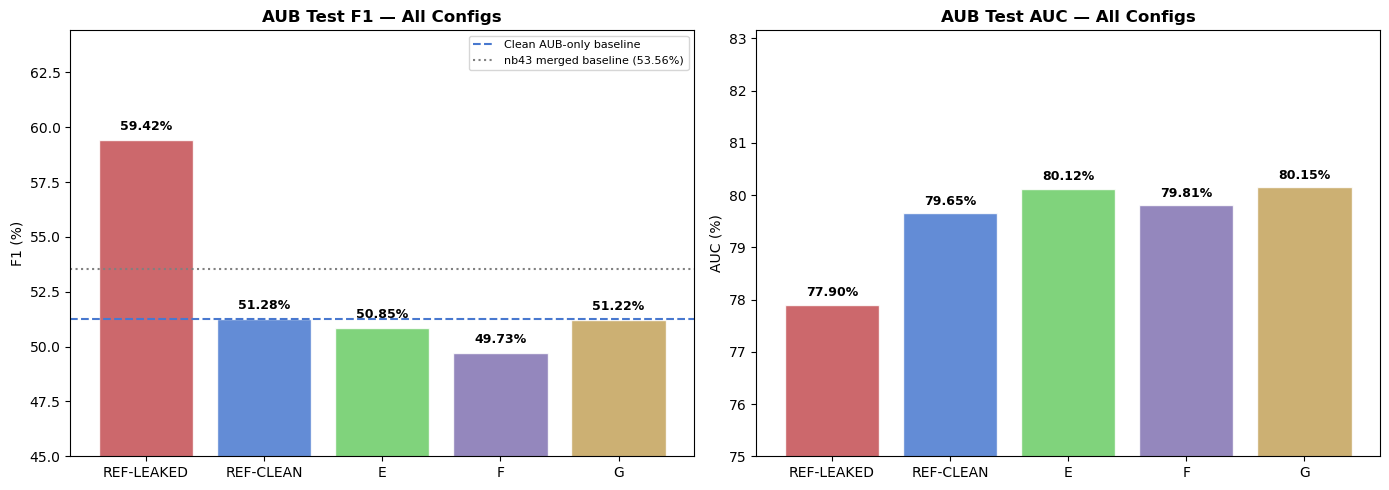

Saved figure


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart: F1 by config ────────────────────────────────────────────────────
ax = axes[0]
config_order = ['REF-LEAKED', 'REF-CLEAN', 'E', 'F', 'G']
f1_vals = [results[k]['f1'] * 100 for k in config_order]
colors  = ['#c44e52', '#4878cf', '#6acc65', '#8172b2', '#c4a35a']

bars = ax.bar(config_order, f1_vals, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(results['REF-CLEAN']['f1'] * 100, color='#4878cf', linestyle='--',
           linewidth=1.5, label='Clean AUB-only baseline')
ax.axhline(NB43_MERGED_F1 * 100, color='grey', linestyle=':', linewidth=1.5,
           label=f'nb43 merged baseline ({NB43_MERGED_F1*100:.2f}%)')

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('AUB Test F1 — All Configs', fontweight='bold')
ax.set_ylabel('F1 (%)')
ax.set_ylim(45, max(f1_vals) + 5)
ax.legend(fontsize=8)

# ── AUC comparison ────────────────────────────────────────────────────────────
ax2 = axes[1]
auc_vals = [results[k]['auc'] * 100 for k in config_order]
bars2 = ax2.bar(config_order, auc_vals, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, auc_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('AUB Test AUC — All Configs', fontweight='bold')
ax2.set_ylabel('AUC (%)')
ax2.set_ylim(75, max(auc_vals) + 3)

plt.tight_layout()
plt.savefig('../../reports/figures/51_institution_norm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure')

## 12. Feature importance — do normalised features rank higher?

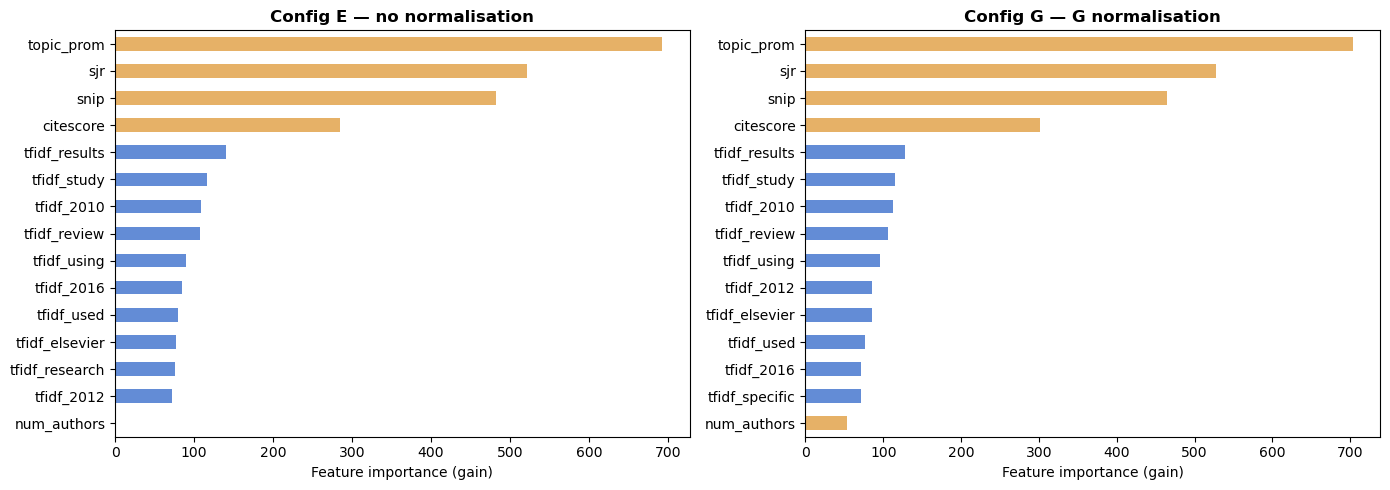

Orange = venue/author features, Blue = TF-IDF features


In [14]:
# Compare feature importances for Config E (no norm) vs best normalised config
best_norm_key = max(['F', 'G'], key=lambda k: results[k]['f1'])
best_norm_model = lgbm_f if best_norm_key == 'F' else lgbm_g
best_norm_X     = X_tr_f if best_norm_key == 'F' else X_tr_g

imp_e = pd.Series(lgbm_e.feature_importances_, index=X_tr_e.columns)
imp_norm = pd.Series(best_norm_model.feature_importances_, index=best_norm_X.columns)

venue_feat_names = list(NORM_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title in [
    (axes[0], imp_e,    'Config E — no normalisation'),
    (axes[1], imp_norm, f'Config {best_norm_key} — {best_norm_key} normalisation'),
]:
    venue_imp  = imp[[c for c in imp.index if c in venue_feat_names]].sort_values(ascending=False)
    top_tfidf  = imp[[c for c in imp.index if c.startswith('tfidf_')]].nlargest(10)

    combined = pd.concat([venue_imp, top_tfidf]).sort_values(ascending=False).head(20)
    combined.plot(kind='barh', ax=ax, color=[
        '#E2A44C' if not c.startswith('tfidf_') else '#4878cf'
        for c in combined.index
    ], alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Feature importance (gain)')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../reports/figures/51_feature_importance_norm_vs_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Orange = venue/author features, Blue = TF-IDF features')

## 13. Findings & next steps

In [15]:
print('=' * 80)
print('NB51 FINDINGS')
print('=' * 80)

leaked_f1  = results['REF-LEAKED']['f1'] * 100
clean_f1   = results['REF-CLEAN']['f1'] * 100
e_f1       = results['E']['f1'] * 100
f_f1       = results['F']['f1'] * 100
g_f1       = results['G']['f1'] * 100
best_merged_f1 = max(e_f1, f_f1, g_f1)

print(f"""
1. LEAKAGE CORRECTION
   Leaked AUB baseline (nb23 bug):   {leaked_f1:.2f}%
   Clean AUB baseline (train thr):   {clean_f1:.2f}%
   Leakage inflation:                {leaked_f1 - clean_f1:+.2f}pp

   The true AUB-only ceiling is {clean_f1:.2f}%, not {leaked_f1:.2f}%.
   The merged gap to close is ~{best_merged_f1 - clean_f1:+.2f}pp, not −8.99pp.

2. INSTITUTION-LEVEL FEATURE NORMALIZATION
   Config E (per-inst labels, no norm):   {e_f1:.2f}%
   Config F (per-inst labels, z-score):   {f_f1:.2f}%
   Config G (per-inst labels, rank norm): {g_f1:.2f}%

   Best normalised config vs E:  {max(f_f1, g_f1) - e_f1:+.2f}pp
   Best merged vs clean baseline: {best_merged_f1 - clean_f1:+.2f}pp
""".strip())

print()
print('RECOMMENDED NEXT EXPERIMENTS')
print('─' * 60)
print(' 1. AUB-only TF-IDF (fit on AUB train only) + best norm config')
print('    → removes vocabulary drift from peer domains')
print(' 2. Domain-matched peer sampling (Medicine/Health only from peers)')
print('    → Lehigh Engineering papers add noise, not signal')
print(' 3. Two-stage: pre-train on merged → fine-tune on AUB-only')
print('    → standard transfer learning, expected 2-4pp gain')

NB51 FINDINGS
1. LEAKAGE CORRECTION
   Leaked AUB baseline (nb23 bug):   59.42%
   Clean AUB baseline (train thr):   51.28%
   Leakage inflation:                +8.14pp

   The true AUB-only ceiling is 51.28%, not 59.42%.
   The merged gap to close is ~-0.06pp, not −8.99pp.

2. INSTITUTION-LEVEL FEATURE NORMALIZATION
   Config E (per-inst labels, no norm):   50.85%
   Config F (per-inst labels, z-score):   49.73%
   Config G (per-inst labels, rank norm): 51.22%

   Best normalised config vs E:  +0.37pp
   Best merged vs clean baseline: -0.06pp

RECOMMENDED NEXT EXPERIMENTS
────────────────────────────────────────────────────────────
 1. AUB-only TF-IDF (fit on AUB train only) + best norm config
    → removes vocabulary drift from peer domains
 2. Domain-matched peer sampling (Medicine/Health only from peers)
    → Lehigh Engineering papers add noise, not signal
 3. Two-stage: pre-train on merged → fine-tune on AUB-only
    → standard transfer learning, expected 2-4pp gain
